In [1]:
# LIBRARIES

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize, RobustScaler
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from scipy.stats import chi2_contingency

import warnings
# I've resolved future warnings as much as I can, but there's a groupby one that persists and is apparently a bug, so I'm turning them off.
warnings.simplefilter(action='ignore', category=FutureWarning)

# Colour Scheme
pal = sns.color_palette()
#print(pal.as_hex())

gender_palette = ['#e377c2', '#1f77b4'] # Hue colours for gender plots.
binary_palette = ['#ff7f0e', '#1f77b4'] # Hack for Got_Text by Booking_Mth graph.


In [2]:
# DATASET

df = pd.read_csv("KaggleV2-May-2016.csv")
print(df.shape)
df.head()

(110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,29872499824296,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# PREPROCESSING

# Check for duplicate rows
duplicates = len(df[df.duplicated()])
print(duplicates, ' duplicate rows')

# Check for null values.
nulls = df.isnull().sum().sum()
print(nulls, ' null values')

# Check outliers
df['Age'].describe() # Min is -1, oldest is 115
df.query('Age < 0 or Age > 100') # 8 records of 5 patients. One -1, two 102, two 115.
# Delete records where Age is -1 or 115. Keep 102.

df = df.query('Age >= 0 and Age < 110')
df['Age'].describe()

# Check value_counts
cols = ['Gender', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']

for col in cols:
    print(df[col].value_counts())
    
# All except Handcap are binary.
# According to dataset author, Handcap is the number of different disabilities the person has so can be more than one.

df['Neighbourhood'].unique() # Can't see any spelling variation.

df['AppointmentID'].describe() # Looks consistent

#Rename columns for consistency and better description
df = df.rename(columns = {'PatientId' : 'Patient_ID', 'AppointmentID' :  'Apmt_ID', 'Scholarship' : 'Gets_Benefits',
                         'Hipertension' : 'Hypertension', 'Handcap' :  'Num_Disabilities', 'SMS_received' : 'Got_Text',
                         'No-show' : 'Missed_Apmt'})

# Disability might work better as a binary.
df['Got_Disability'] = [0 if x == 0 else 1 for x in df['Num_Disabilities']]
print(df['Got_Disability'].value_counts())

#df.dtypes
df.head()

0  duplicate rows
0  null values
Gender
F    71834
M    38687
Name: count, dtype: int64
Scholarship
0    99660
1    10861
Name: count, dtype: int64
Hipertension
0    88721
1    21800
Name: count, dtype: int64
Diabetes
0    102578
1      7943
Name: count, dtype: int64
Alcoholism
0    107161
1      3360
Name: count, dtype: int64
Handcap
0    108284
1      2038
2       183
3        13
4         3
Name: count, dtype: int64
SMS_received
0    75040
1    35481
Name: count, dtype: int64
No-show
No     88205
Yes    22316
Name: count, dtype: int64
Got_Disability
0    108284
1      2237
Name: count, dtype: int64


,Patient_ID,Apmt_ID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Gets_Benefits,Hypertension,Diabetes,Alcoholism,Num_Disabilities,Got_Text,Missed_Apmt,Got_Disability
0,29872499824296,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0
1,558997776694438,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0
2,4262962299951,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No,0
3,867951213174,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0
4,8841186448183,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0


Neighbourhood
MORADA DE CAMBURI              96
PONTAL DE CAMBURI              69
ILHA DO BOI                    35
ILHA DO FRADE                  10
AEROPORTO                       8
ILHAS OCEÂNICAS DE TRINDADE     2
PARQUE INDUSTRIAL               1
Name: count, dtype: int64


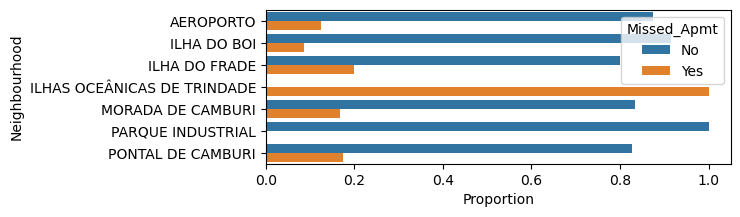

221 deleted rows


Text(0.5, 1.0, 'Percentage of Missed Appointments by Neighbourhood')

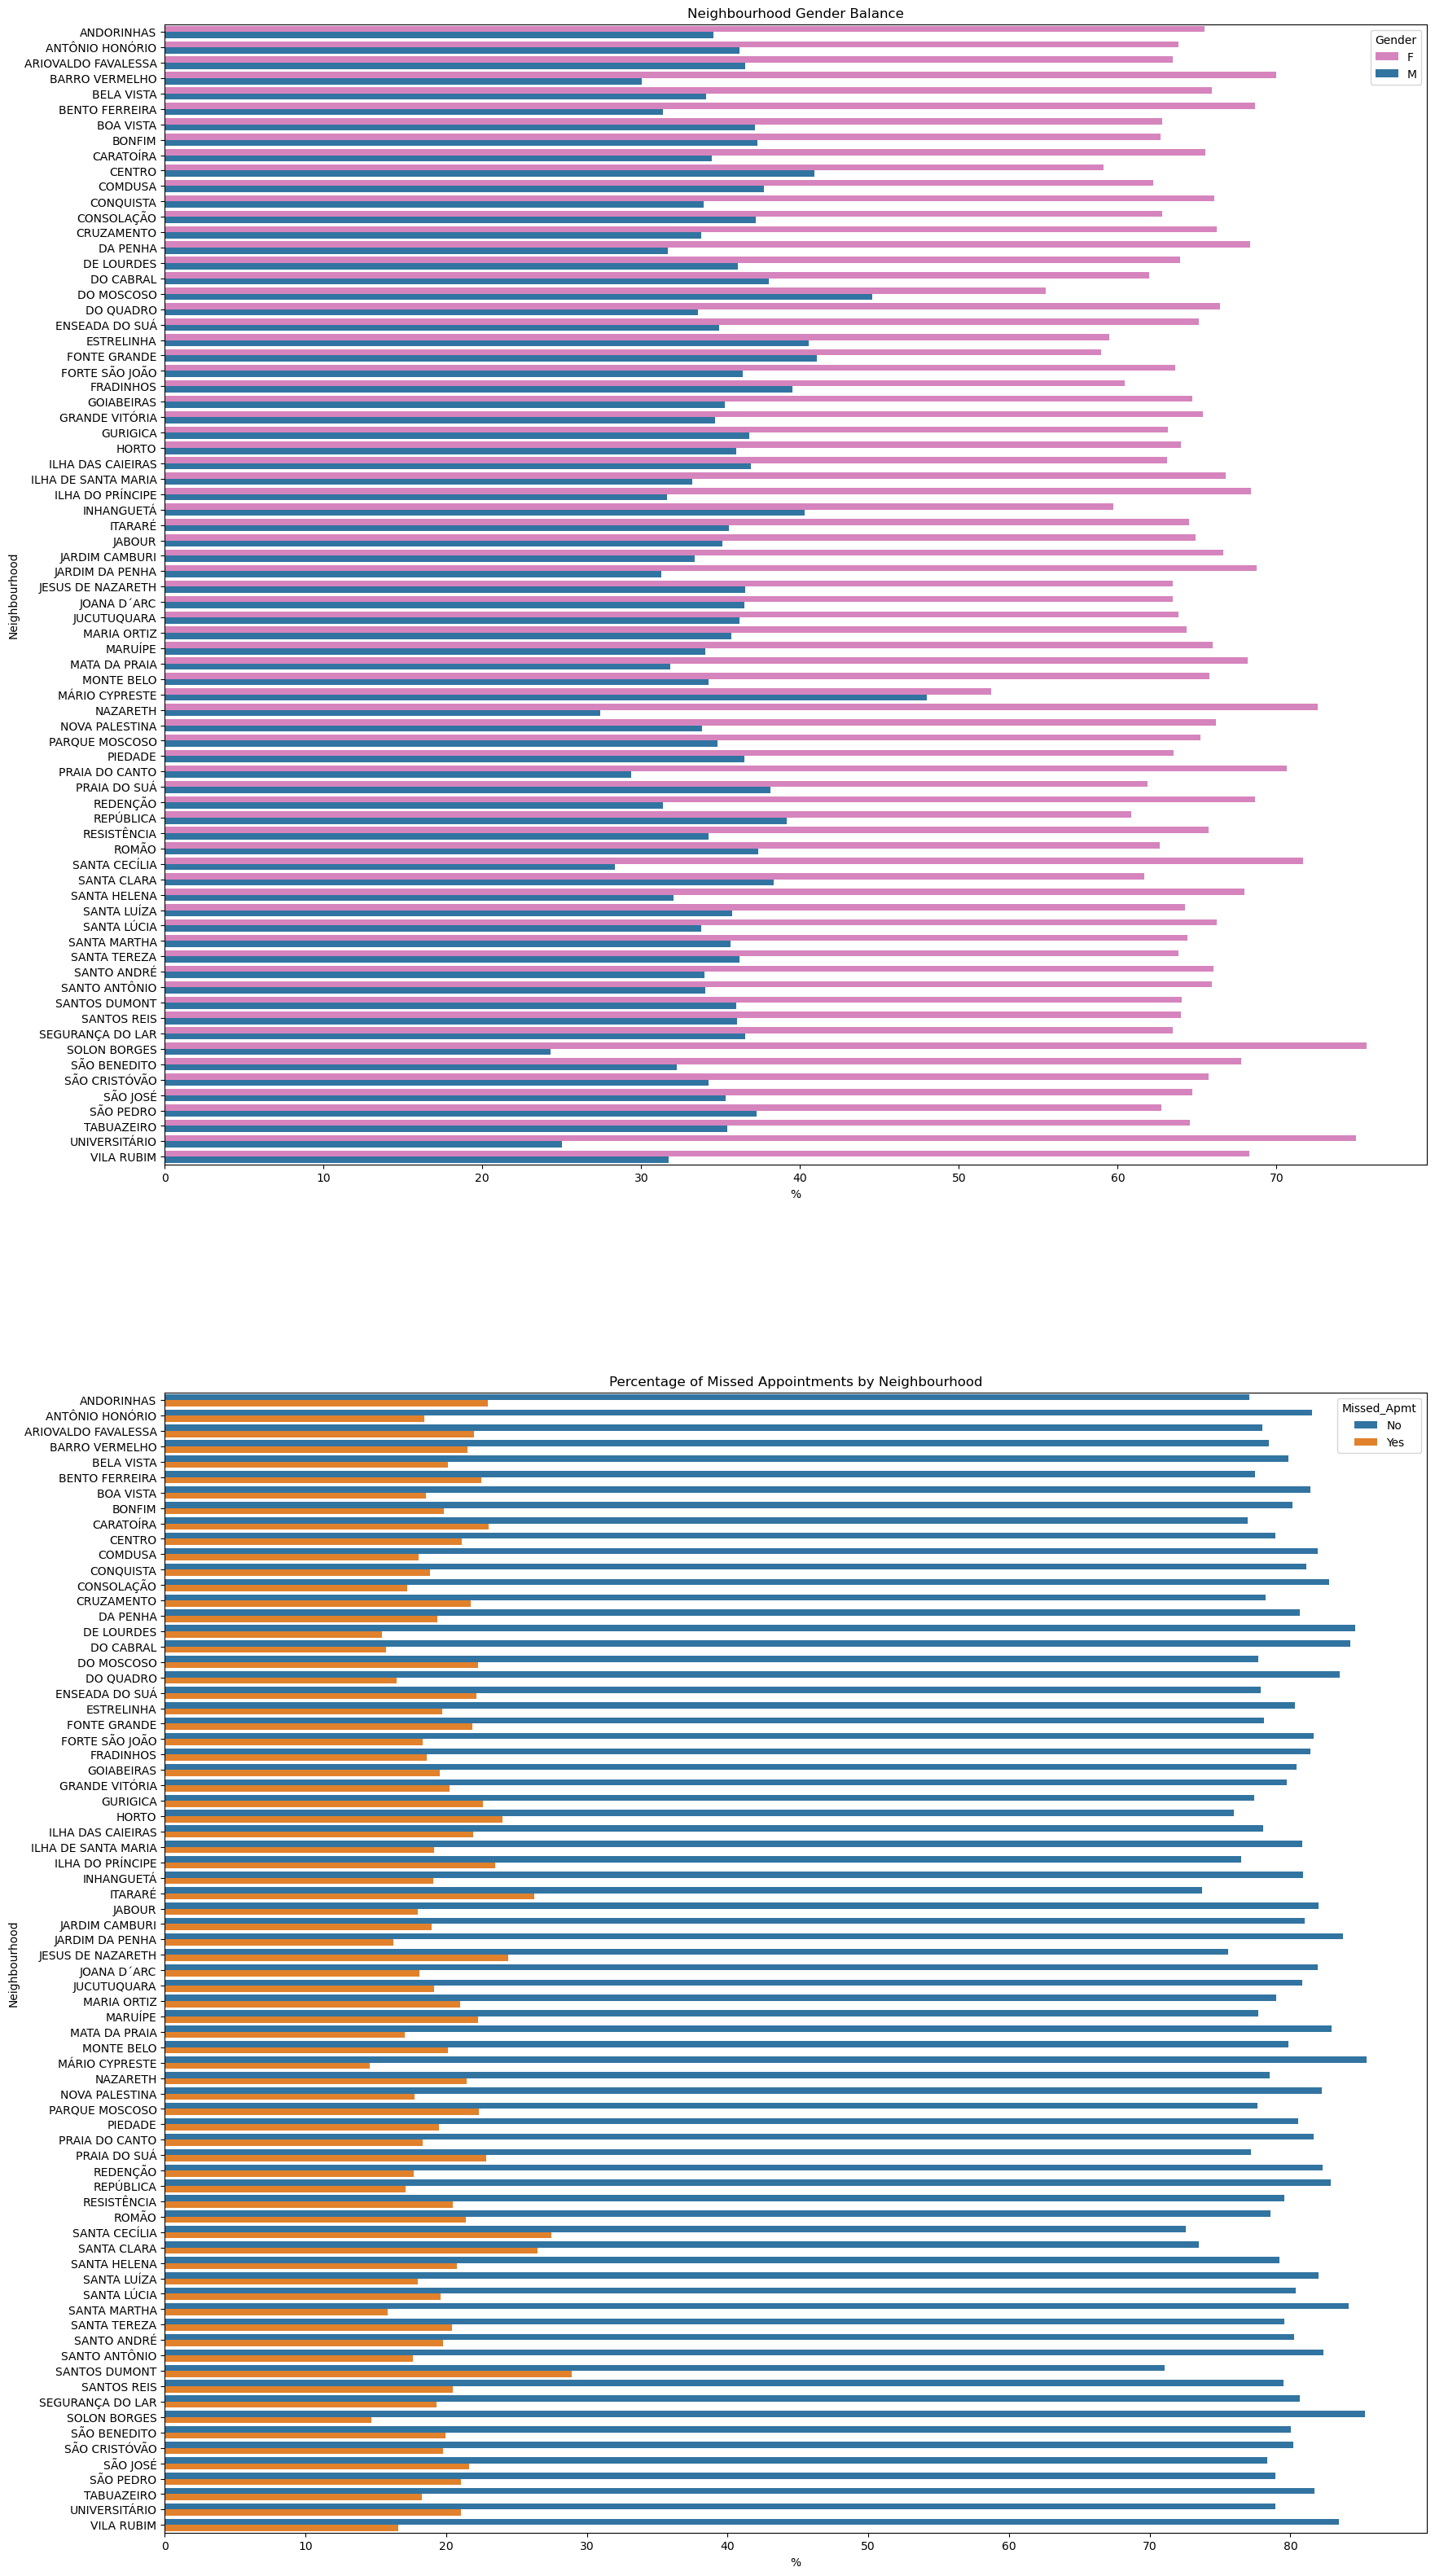

In [4]:
# NEIGHBOURHOODS

# NB This is by appointment, not patient ID.

"""
NB The neighbourhood is where the appointment took place, not where the patients live.
Distance travelled to the appointment may well be a factor, and some areas may be better served by public transport than
others, but there's no information on that.
"""

low_counts = df['Neighbourhood'].value_counts().loc[lambda x: x<100]
print(low_counts)

"""
The fewer instances there are for a neighbourhood, the more likely that any patterns in the data will be due to chance.
If this were going into production, I would seek out more data for these areas.
For this, I'm going to drop rows from neighbourhoods with less than 100 instances and state in the model card that use for
other areas is out of scope, on the basis that it's better that the model not be used if it's unreliable.
"""

drop_hoods = low_counts.index.to_list()

small_hoods = df[df['Neighbourhood'].isin(drop_hoods)].groupby('Neighbourhood')['Missed_Apmt'].value_counts(normalize = True).reset_index(name='Proportion')
#print(small_hoods)
fig, ax = plt.subplots(figsize = (6,2))
sns.barplot(x = 'Proportion', y = 'Neighbourhood', hue = 'Missed_Apmt', data = small_hoods)
plt.show()

# There's a couple there that deviate significantly from the overall proportions, but there's not enough data to know if they're meaningful.

print(len(df[df['Neighbourhood'].isin(drop_hoods)]), 'deleted rows')
df = df[~ df['Neighbourhood'].isin(drop_hoods)]

hoods = df['Neighbourhood'].unique()
used_hoods = list(set(hoods) - set(drop_hoods))
#print(sorted(used_hoods)) # For the model card.

# Variation

fig, ax = plt.subplots(2,1, figsize = (20,40))

group_nei = df.groupby(['Neighbourhood', 'Gender'], observed = True).size().reset_index(name='Count')
group_nei['Total'] = group_nei.groupby('Neighbourhood', observed = True)['Count'].transform('sum')
group_nei['%'] = 100* group_nei['Count'] / group_nei['Total']

#print(group_nei)

sns.barplot(x = '%', y = 'Neighbourhood', hue = 'Gender', data = group_nei, palette = gender_palette, ax = ax[0])
ax[0].set_title('Neighbourhood Gender Balance')

# More appointments for women in every area, but the gap is much larger in some than others.

miss_nei = df.groupby(['Neighbourhood', 'Missed_Apmt'], observed = True).size().reset_index(name='Count')
miss_nei['Total'] =  miss_nei.groupby('Neighbourhood', observed = True)['Count'].transform('sum')
miss_nei['%'] = 100* miss_nei['Count'] / miss_nei['Total']

miss_nei['Missed_Apmt'] = miss_nei['Missed_Apmt'].astype('str')

sns.barplot(x = '%', y = 'Neighbourhood', hue = 'Missed_Apmt', data = miss_nei, ax = ax[1])
ax[1].set_title('Percentage of Missed Appointments by Neighbourhood')

# There's some significant differences here as well.

Missed_Apmt
No     0.798005
Yes    0.201995
Name: proportion, dtype: float64
62146
Gender proportions - Patients Gender
F    0.642873
M    0.357127
Name: Patient_ID, dtype: float64
  Gender Missed_Apmt  Proportion
0      F          No    0.796834
1      F         Yes    0.203166
2      M          No    0.800181
3      M         Yes    0.199819


Text(0.5, 1.0, 'Proportion of Missed_Apmt by Gender')

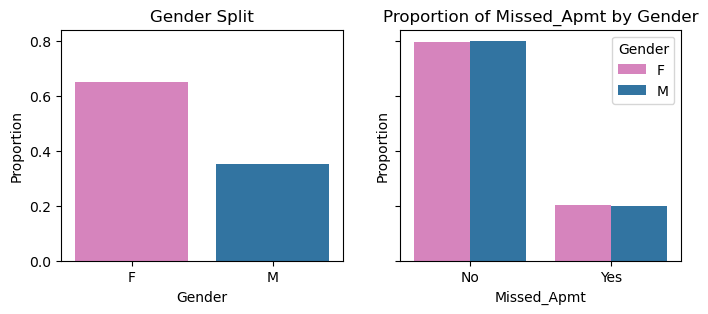

In [5]:
# TARGET VARIABLE

# Overall proportions of Missed_Apmt
print(df['Missed_Apmt'].value_counts(normalize = True))

# Gender proportions - Appointments
gen = df['Gender'].value_counts(normalize=True).reset_index(name = 'Proportion') # All M or F

# Gender proportions - Patients
total_patients = df['Patient_ID'].nunique()
print(total_patients)
gen_pat = df.groupby('Gender')['Patient_ID'].nunique() / total_patients
print('Gender proportions - Patients', gen_pat) # Roughly the same.

fig, ax = plt.subplots(1,2,figsize = (8, 3), sharey = True) # This figsize works better for report.
sns.barplot(x = 'Gender', y = 'Proportion', data = gen, palette = gender_palette, ax = ax[0])
ax[0].set_title('Gender Split')

# Proportions by gender
df_gender = df.groupby('Gender', observed = True)['Missed_Apmt'].value_counts(normalize = True).reset_index(name = 'Proportion')
print(df_gender)

sns.barplot(x = 'Missed_Apmt', y = 'Proportion', data = df_gender, hue = 'Gender', palette = gender_palette, ax = ax[1])
ax[1].set_title('Proportion of Missed_Apmt by Gender')

# More women than men, but the proportion of missed appointments is basically equal.
# Data is not synthetic. Pre-balancing may have been performed - no mention.

In [6]:
# DATES

# Booking

df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])

min_book = df['ScheduledDay'].min()
max_book = df['ScheduledDay'].max()
print('First booking date:', min_book, 'Last booking date:', max_book) # 10 Nov 2015 to 8 June 2016

df['Booking_Mth'] = df['ScheduledDay'].dt.month
df['Booking_Day'] = df['ScheduledDay'].dt.day
df['Booking_DayWeek'] = df['ScheduledDay'].dt.dayofweek

# Appointments

df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

min_apmt = df['AppointmentDay'].min()
max_apmt = df['AppointmentDay'].max()
print('First appointment date:', min_apmt, 'Last appointment date:', max_apmt)
    # Appointments only cover a few weeks, so not enough data for month or day.
    # Also no point in checking if missed previous appointments.

df['Apmt_Hr'] = df['AppointmentDay'].dt.hour
df['Apmt_Hr'].value_counts() # All zero, so remove.
df = df.drop('Apmt_Hr', axis = 'columns')

df['Apmt_DayWeek'] = df['AppointmentDay'].dt.dayofweek

df.head()

First booking date: 2015-11-10 07:13:56+00:00 Last booking date: 2016-06-08 20:07:23+00:00
First appointment date: 2016-04-29 00:00:00+00:00 Last appointment date: 2016-06-08 00:00:00+00:00


,Patient_ID,Apmt_ID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Gets_Benefits,Hypertension,Diabetes,Alcoholism,Num_Disabilities,Got_Text,Missed_Apmt,Got_Disability,Booking_Mth,Booking_Day,Booking_DayWeek,Apmt_DayWeek
0,29872499824296,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,4,29,4,4
1,558997776694438,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,4,29,4,4
2,4262962299951,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,4,29,4,4
4,8841186448183,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0,4,29,4,4
5,95985133231274,5626772,F,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,76,REPÚBLICA,0,1,0,0,0,0,No,0,4,27,2,4


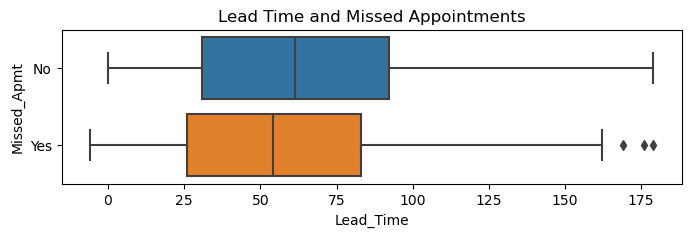

In [7]:
# LEAD TIME

# Time Difference between booking and appointment

df['Lead_Time'] = ((df['AppointmentDay'].dt.date - df['ScheduledDay'].dt.date) / np.timedelta64(1, 'D')).astype('int')

df = df.drop(['ScheduledDay', 'AppointmentDay'], axis = 'columns') # Don't need those anymore.

lead = df.groupby(['Missed_Apmt', 'Lead_Time'], observed = True).size().reset_index(name='Count')

fig, ax = plt.subplots(figsize = (8,2))
sns.boxplot(y = 'Missed_Apmt', x = 'Lead_Time', data = lead)
plt.title('Lead Time and Missed Appointments')
plt.show()

# Clear variation in the distribution of lead times between missed and not missed.

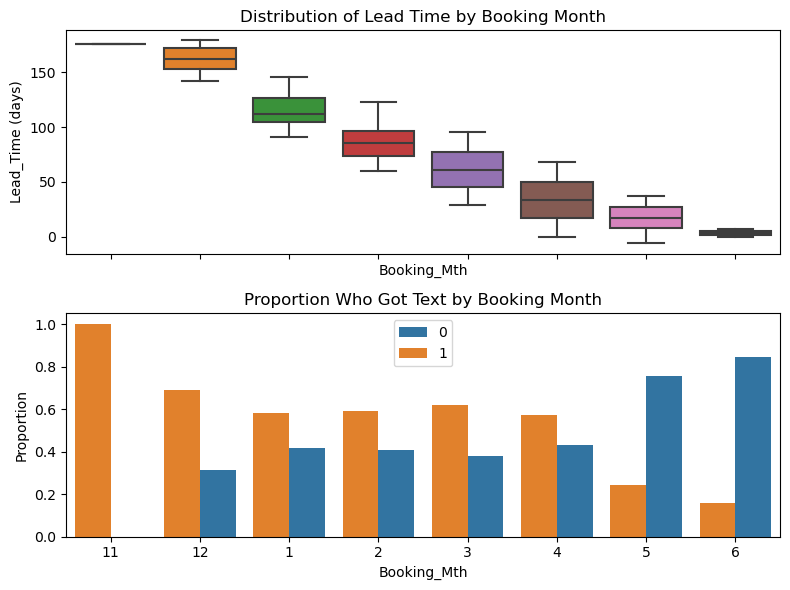

In [8]:
# BOOKING MONTH

# Booking Month and Lead Time - have to wait longer for apmts in some months?
df['Booking_Mth'] = df['Booking_Mth'].astype('category').cat.reorder_categories([11,12,1,2,3,4,5,6], ordered = True)
# Because Nov and Dec come first, reordering months.

fig, ax = plt.subplots(2,1, figsize = (8,6), sharex = True)
lead = df.groupby(['Booking_Mth', 'Lead_Time'], observed = True).size().reset_index(name='Count')
sns.boxplot(x = 'Booking_Mth', y = 'Lead_Time', data = lead, ax = ax[0])
ax[0].set_title('Distribution of Lead Time by Booking Month')
ax[0].set_ylabel('Lead_Time (days)')

# Got Text and Booking Month
text = df.groupby('Booking_Mth', observed = True)['Got_Text'].value_counts(normalize = True).reset_index(name='Proportion')
text['Got_Text'] = text['Got_Text'].astype('str')
sns.barplot(x = 'Booking_Mth', y = 'Proportion', hue = 'Got_Text', palette = binary_palette, data = text, ax = ax[1])
# The palette is because the colours in this one are appearing the opposite way round to all the other graphs, probably
# because November is 100% 1, so I'm switching them.
handles, labels = plt.gca().get_legend_handles_labels()
order = [1,0] # Also switching the legend order, because I'm picky.
plt.legend([handles[i] for i in order], [labels[i] for i in order]) 
ax[1].set_title('Proportion Who Got Text by Booking Month')

#print(text) # Proportion who got text varies dramatically by month.

plt.tight_layout()

# Given that we haven't got all the months represented, and both Lead_Time and Got_Text vary a lot with it, not going to use Booking_Mth.

df = df.drop('Booking_Mth', axis = 'columns')


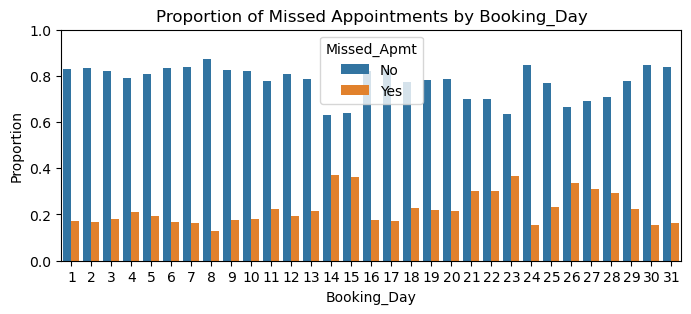

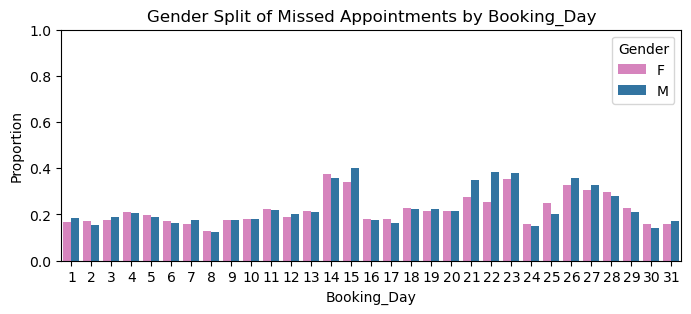

In [9]:
# DAY

fig, ax = plt.subplots(figsize = (8,3))

book_day = df.groupby('Booking_Day')['Missed_Apmt'].value_counts(normalize = True).reset_index(name = 'Proportion')
sns.barplot(x = 'Booking_Day', y = 'Proportion', data = book_day, hue = 'Missed_Apmt')
plt.ylim(0,1)
plt.title('Proportion of Missed Appointments by Booking_Day')
plt.show()

# Definitely some variation, although not massive.

fig, ax = plt.subplots(figsize = (8,3))
gen_day = df.groupby(['Booking_Day', 'Gender'])['Missed_Apmt'].value_counts(normalize = True).reset_index(name = 'Proportion')
gen_day = gen_day.loc[gen_day['Missed_Apmt'] == 'Yes', :]
#print(gen_day)
sns.barplot(x = 'Booking_Day', y = 'Proportion', data = gen_day, hue = 'Gender', palette = gender_palette)
plt.ylim(0,1) # Not adjusting the axis limits makes the differences look larger than they are.
plt.title('Gender Split of Missed Appointments by Booking_Day')
plt.show()

# Small differences on a few days, but nothing significant.

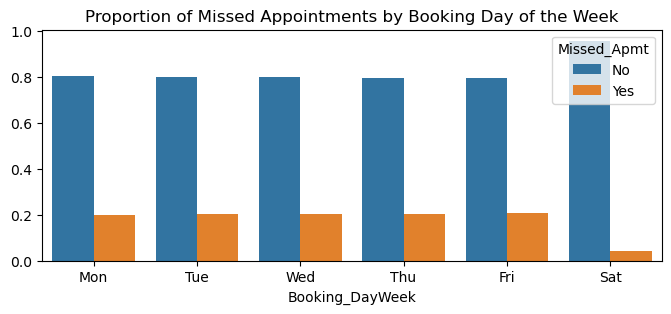

Appointments booked on Saturdays: 24
Neighbourhoods with Saturday bookings: 13 of 74


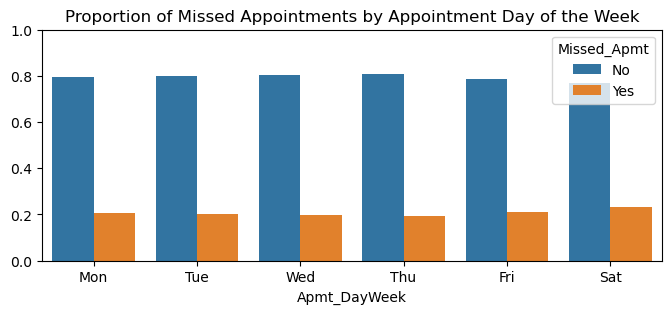

In [10]:
# DAY OF THE WEEK

book_week = df.groupby('Booking_DayWeek')['Missed_Apmt'].value_counts(normalize = True).reset_index(name = 'Proportion')
book_week['Booking_DayWeek'] = book_week['Booking_DayWeek'].replace({0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'})
fig, ax = plt.subplots(figsize = (8,3))
sns.barplot(x = 'Booking_DayWeek', y = 'Proportion', data = book_week, hue = 'Missed_Apmt')
plt.title('Proportion of Missed Appointments by Booking Day of the Week')
plt.ylabel('')
plt.show()

# Booking on a Saturday appears to make it less likely you'll miss it. 
print('Appointments booked on Saturdays:', df[df['Booking_DayWeek'] == 5]['Apmt_ID'].count())
# There's only 24, so this isn't a reliable pattern.
print('Neighbourhoods with Saturday bookings:', df[df['Booking_DayWeek'] == 5]['Neighbourhood'].nunique(), 'of', df['Neighbourhood'].nunique())
# Only 13 of 74, so that's strongly related to neighbourhood as well.

apmt_week = df.groupby('Apmt_DayWeek')['Missed_Apmt'].value_counts(normalize = True).reset_index(name = 'Proportion')
apmt_week['Apmt_DayWeek'] = apmt_week['Apmt_DayWeek'].replace({0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'})
fig, ax = plt.subplots(figsize = (8,3))
sns.barplot(x = 'Apmt_DayWeek', y = 'Proportion', data = apmt_week, hue = 'Missed_Apmt')
plt.ylim(ymax = 1.0)
plt.title('Proportion of Missed Appointments by Appointment Day of the Week')
plt.ylabel('')
plt.show()

# No change in Apmt dates. Not convinced there's enough data to use it anyway.

df = df.drop('Apmt_DayWeek', axis = 'columns')

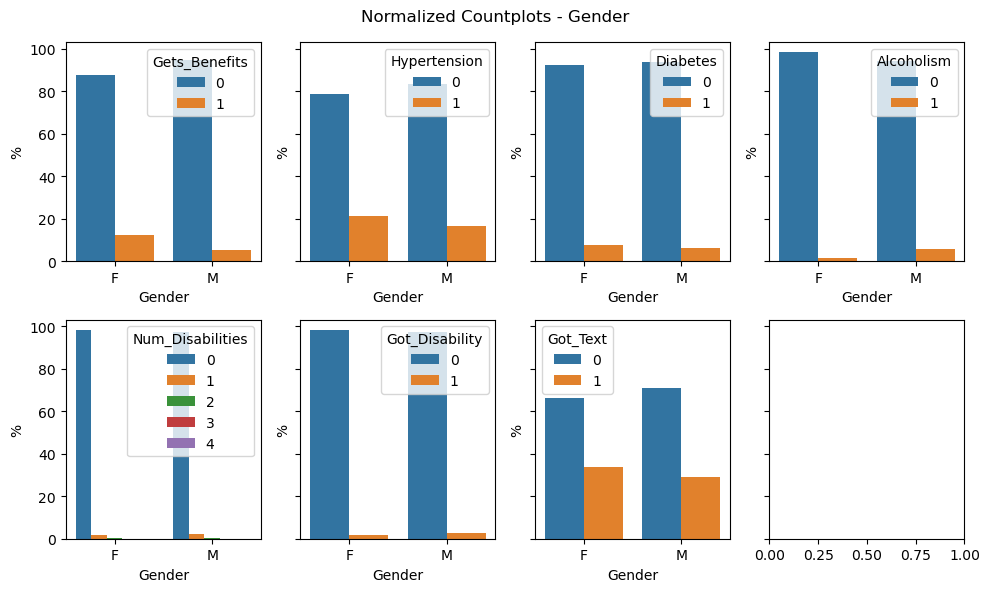

In [11]:
# NORMALISED PLOTS - GENDER
# Normalisation to account for there being more women than men.

fig, axs = plt.subplots(2,4, figsize = (10,6), sharey = True) 
#sharey means they all use the same yaxis, which is a quick way to keep them all on the same scale.

# Gets_Benefits
group_ben = df.groupby(['Gender', 'Gets_Benefits'], observed = True).size().reset_index(name='Count')
group_ben['Total'] = group_ben.groupby('Gender', observed = True)['Count'].transform('sum')
group_ben['%'] = 100* group_ben['Count'] / group_ben['Total']

group_ben['Gets_Benefits'] = group_ben['Gets_Benefits'].astype('str') # It gets confused by numerical hues.

sns.barplot(x = 'Gender', y = '%', hue = 'Gets_Benefits', data = group_ben, ax = axs[0,0])
plt.suptitle('Normalized Countplots - Gender')

# Hypertension

group_hyp = df.groupby(['Gender', 'Hypertension'], observed = True).size().reset_index(name='Count')
group_hyp['Total'] = group_hyp.groupby('Gender', observed = True)['Count'].transform('sum')
group_hyp['%'] = 100* group_hyp['Count'] / group_hyp['Total']

group_hyp['Hypertension'] = group_hyp['Hypertension'].astype('str')

sns.barplot(x = 'Gender', y = '%', hue = 'Hypertension', data = group_hyp, ax = axs[0,1])

# Diabetes

group_dia = df.groupby(['Gender', 'Diabetes'], observed = True).size().reset_index(name='Count')
group_dia['Total'] = group_dia.groupby('Gender', observed = True)['Count'].transform('sum')
group_dia['%'] = 100* group_dia['Count'] / group_dia['Total']

group_dia['Diabetes'] = group_dia['Diabetes'].astype('str')

sns.barplot(x = 'Gender', y = '%', hue = 'Diabetes', data = group_dia, ax = axs[0,2])

# Alcoholism

group_alc = df.groupby(['Gender', 'Alcoholism'], observed = True).size().reset_index(name='Count')
group_alc['Total'] = group_alc.groupby('Gender', observed = True)['Count'].transform('sum')
group_alc['%'] = 100* group_alc['Count'] / group_alc['Total']

group_alc['Alcoholism'] = group_alc['Alcoholism'].astype('str')

sns.barplot(x = 'Gender', y = '%', hue = 'Alcoholism', data = group_alc, ax = axs[0,3])

# Num Disabilities

group_dis = df.groupby(['Gender', 'Num_Disabilities'], observed = True).size().reset_index(name='Count')
group_dis['Total'] = group_dis.groupby('Gender', observed = True)['Count'].transform('sum')
group_dis['%'] = 100* group_dis['Count'] / group_dis['Total']

group_dis['Num_Disabilities'] = group_dis['Num_Disabilities'].astype('str')

sns.barplot(x = 'Gender', y = '%', hue = 'Num_Disabilities', data = group_dis, ax = axs[1,0])

# Got Disability

group_dis2 = df.groupby(['Gender', 'Got_Disability'], observed = True).size().reset_index(name='Count')
group_dis2['Total'] = group_dis2.groupby('Gender', observed = True)['Count'].transform('sum')
group_dis2['%'] = 100* group_dis2['Count'] / group_dis2['Total']

group_dis2['Got_Disability'] = group_dis2['Got_Disability'].astype('str')

sns.barplot(x = 'Gender', y = '%', hue = 'Got_Disability', data = group_dis2, ax = axs[1,1])

# Got Text

group_txt = df.groupby(['Gender', 'Got_Text'], observed = True).size().reset_index(name='Count')
group_txt['Total'] = group_txt.groupby('Gender', observed = True)['Count'].transform('sum')
group_txt['%'] = 100* group_txt['Count'] / group_txt['Total']

group_txt['Got_Text'] = group_txt['Got_Text'].astype('str')

sns.barplot(x = 'Gender', y = '%', hue = 'Got_Text', data = group_txt, ax = axs[1,2])
plt.tight_layout()

# There are some gender differences, but none of the other variables appear to be a proxy for gender.

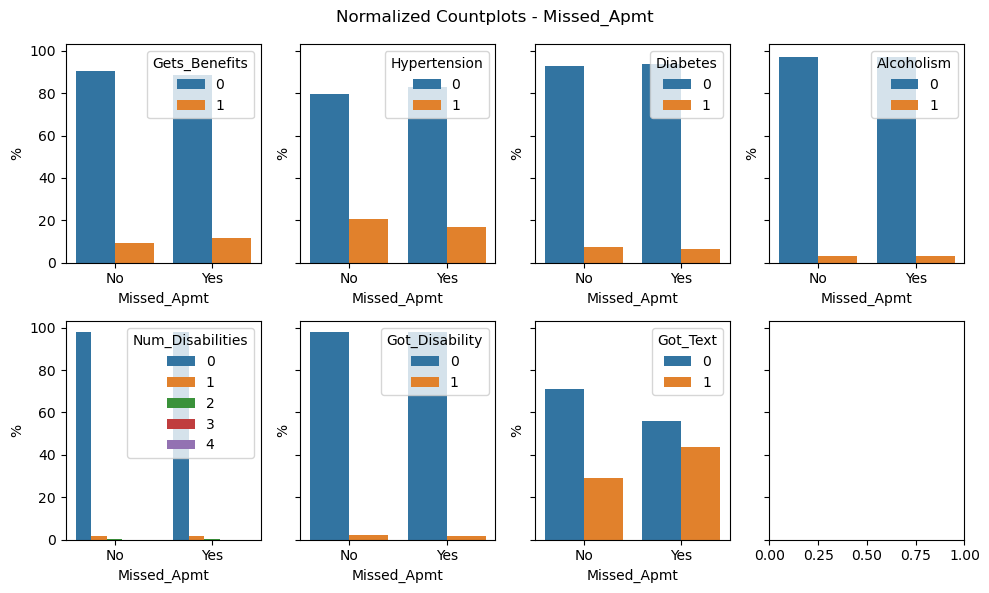

In [12]:
# NORMALISED PLOTS - MISSED APPOINTMENTS

fig, axs = plt.subplots(2,4, figsize = (10,6), sharey = True)

# Gets_Benefits

group_ben = df.groupby(['Missed_Apmt', 'Gets_Benefits'], observed = True).size().reset_index(name='Count')
group_ben['Total'] = group_ben.groupby('Missed_Apmt', observed = True)['Count'].transform('sum')
group_ben['%'] = 100* group_ben['Count'] / group_ben['Total']

group_ben['Gets_Benefits'] = group_ben['Gets_Benefits'].astype('str') # It gets confused by numerical hues.

sns.barplot(x = 'Missed_Apmt', y = '%', hue = 'Gets_Benefits', data = group_ben, ax = axs[0,0])
plt.suptitle('Normalized Countplots - Missed_Apmt')

# Hypertension

group_hyp = df.groupby(['Missed_Apmt', 'Hypertension'], observed = True).size().reset_index(name='Count')
group_hyp['Total'] = group_hyp.groupby('Missed_Apmt', observed = True)['Count'].transform('sum')
group_hyp['%'] = 100* group_hyp['Count'] / group_hyp['Total']

group_hyp['Hypertension'] = group_hyp['Hypertension'].astype('str')

sns.barplot(x = 'Missed_Apmt', y = '%', hue = 'Hypertension', data = group_hyp, ax = axs[0,1])

# Diabetes

group_dia = df.groupby(['Missed_Apmt', 'Diabetes'], observed = True).size().reset_index(name='Count')
group_dia['Total'] = group_dia.groupby('Missed_Apmt', observed = True)['Count'].transform('sum')
group_dia['%'] = 100* group_dia['Count'] / group_dia['Total']

group_dia['Diabetes'] = group_dia['Diabetes'].astype('str')

sns.barplot(x = 'Missed_Apmt', y = '%', hue = 'Diabetes', data = group_dia, ax = axs[0,2])

# Alcoholism

group_alc = df.groupby(['Missed_Apmt', 'Alcoholism'], observed = True).size().reset_index(name='Count')
group_alc['Total'] = group_alc.groupby('Missed_Apmt', observed = True)['Count'].transform('sum')
group_alc['%'] = 100* group_alc['Count'] / group_alc['Total']

group_alc['Alcoholism'] = group_alc['Alcoholism'].astype('str')

sns.barplot(x = 'Missed_Apmt', y = '%', hue = 'Alcoholism', data = group_alc, ax = axs[0,3])

# Num Disabilities

group_dis = df.groupby(['Missed_Apmt', 'Num_Disabilities'], observed = True).size().reset_index(name='Count')
group_dis['Total'] = group_dis.groupby('Missed_Apmt', observed = True)['Count'].transform('sum')
group_dis['%'] = 100* group_dis['Count'] / group_dis['Total']

group_dis['Num_Disabilities'] = group_dis['Num_Disabilities'].astype('str')

sns.barplot(x = 'Missed_Apmt', y = '%', hue = 'Num_Disabilities', data = group_dis, ax = axs[1,0])

# Got Disability

group_dis2 = df.groupby(['Missed_Apmt', 'Got_Disability'], observed = True).size().reset_index(name='Count')
group_dis2['Total'] = group_dis2.groupby('Missed_Apmt', observed = True)['Count'].transform('sum')
group_dis2['%'] = 100* group_dis2['Count'] / group_dis2['Total']

group_dis2['Got_Disability'] = group_dis2['Got_Disability'].astype('str')

sns.barplot(x = 'Missed_Apmt', y = '%', hue = 'Got_Disability', data = group_dis2, ax = axs[1,1])

# Got Text

group_txt = df.groupby(['Missed_Apmt', 'Got_Text'], observed = True).size().reset_index(name='Count')
group_txt['Total'] = group_txt.groupby('Missed_Apmt', observed = True)['Count'].transform('sum')
group_txt['%'] = 100* group_txt['Count'] / group_txt['Total']

group_txt['Got_Text'] = group_txt['Got_Text'].astype('str')

sns.barplot(x = 'Missed_Apmt', y = '%', hue = 'Got_Text', data = group_txt, ax = axs[1,2])

plt.tight_layout()

# Got Text looks the most significant. Differences for others are pretty small.

Text(0.5, 1.0, 'Percentage of Missed Appointments by Age Group')

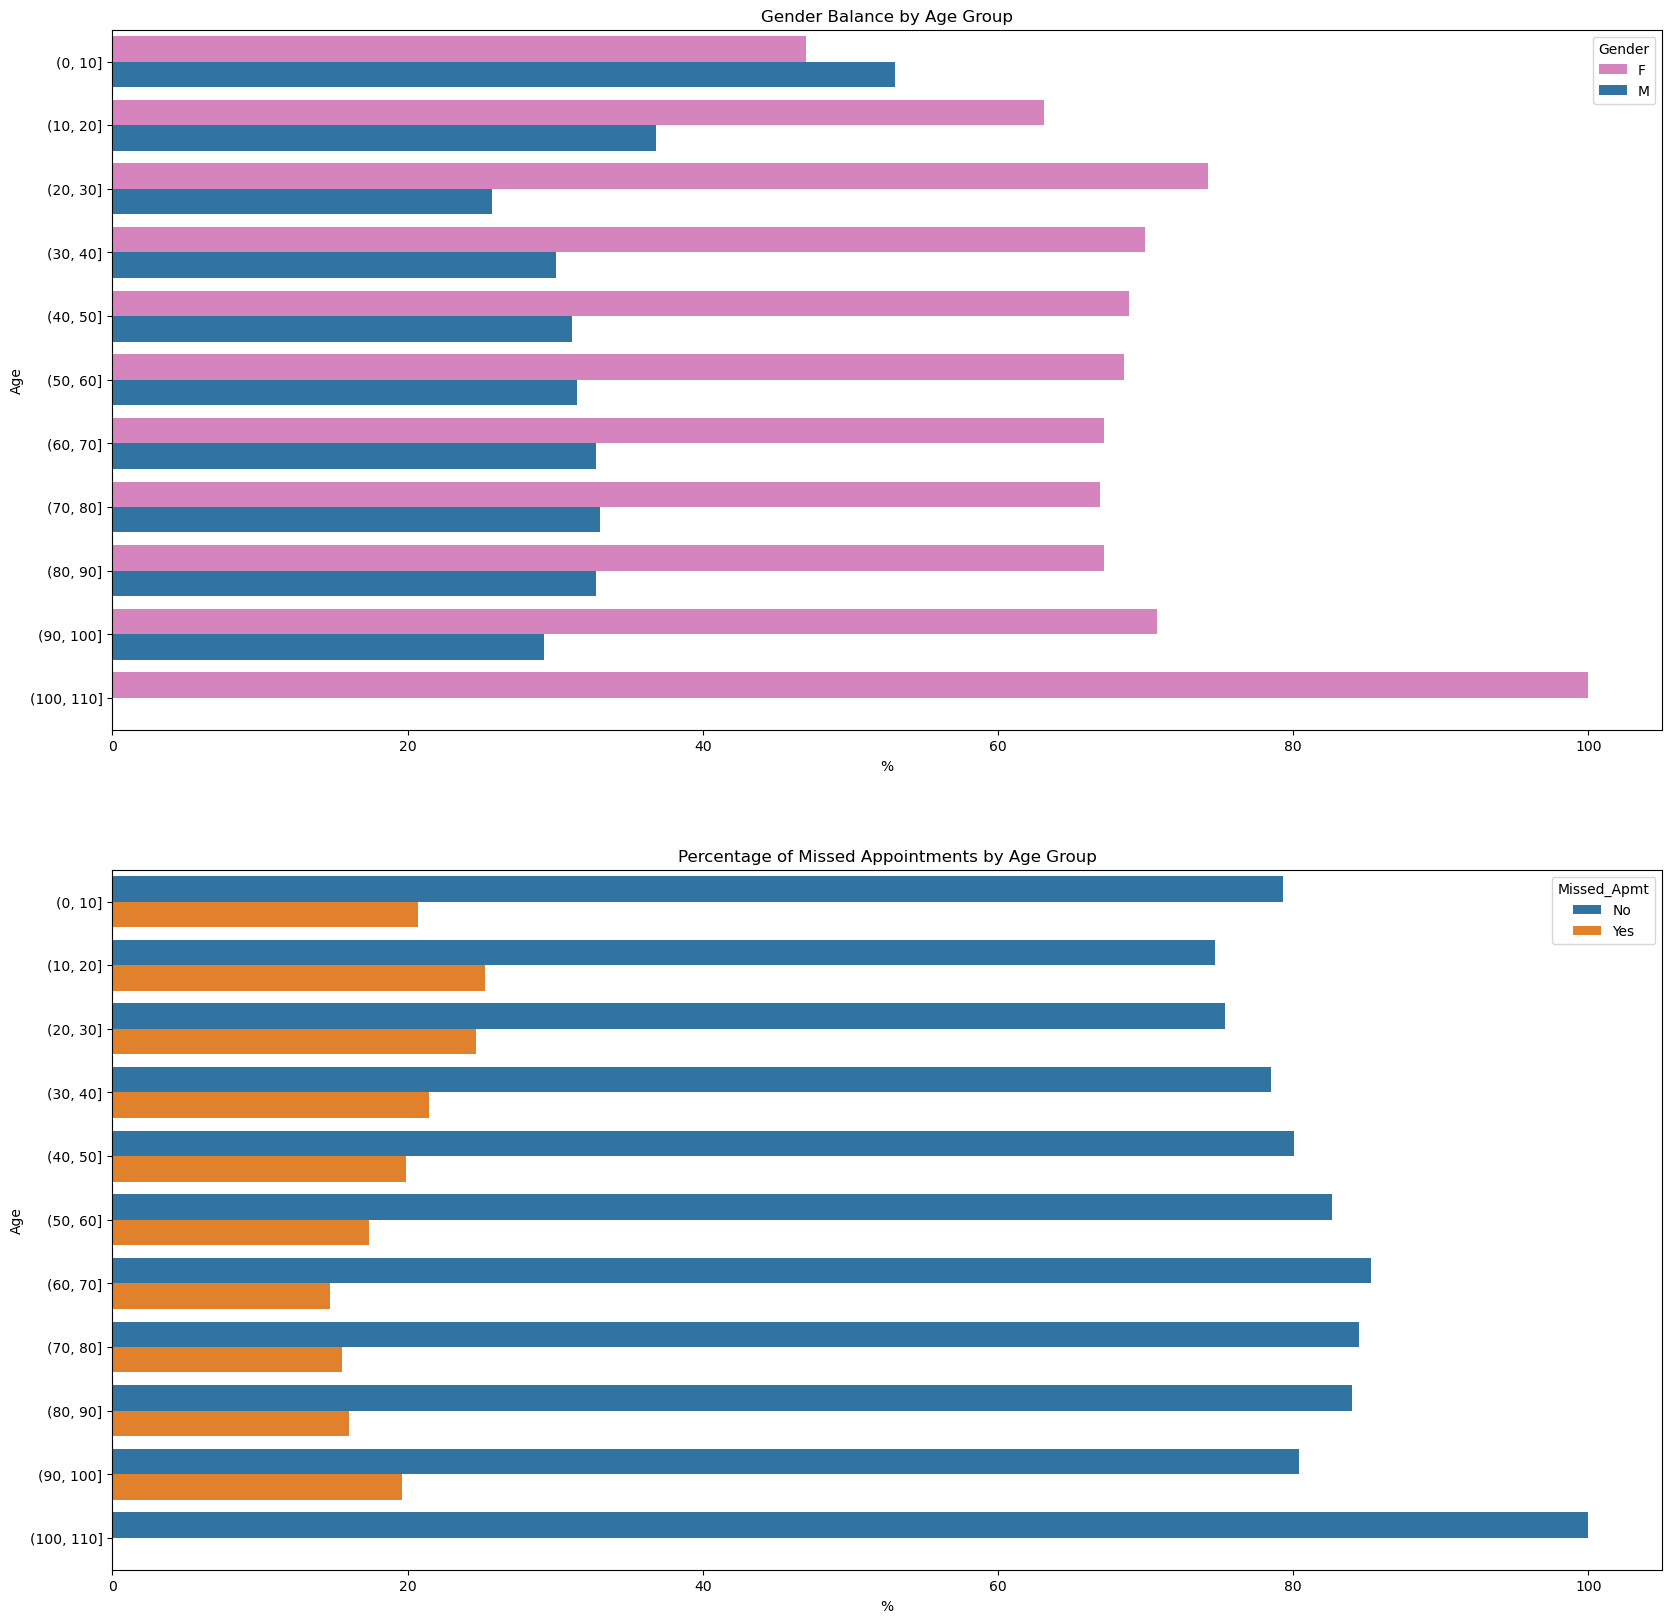

In [13]:
# AGE
# NB This is by appointment, not patient ID.

# Slice the age into decades for the visual.
group_age = df.groupby([pd.cut(df['Age'], np.arange(0, 111, 10)), 'Gender'], observed = True).agg(Count = ('Apmt_ID', 'count')).reset_index()

group_age['Total'] = group_age.groupby('Age', observed = True)['Count'].transform('sum')
group_age['%'] = 100* group_age['Count'] / group_age['Total']

#print(group_age)

fig, ax = plt.subplots(2,1, figsize=(20, 20)) # Just to set plot size.
sns.barplot(y = 'Age', x = '%', hue = 'Gender', data = group_age, palette = gender_palette, ax = ax[0])
ax[0].set_title('Gender Balance by Age Group')
#print(group_age)

# More men than women for under 10 group only. Probably their mothers are bringing them.

miss_age = df.groupby([pd.cut(df['Age'], np.arange(0, 111, 10)), 'Missed_Apmt'], observed = True).agg(Count = ('Apmt_ID', 'count')).reset_index()

miss_age['Total'] = miss_age.groupby('Age', observed = True)['Count'].transform('sum')
miss_age['%'] = 100* miss_age['Count'] / miss_age['Total']

#print(miss_age)

miss_age['Missed_Apmt'] = miss_age['Missed_Apmt'].astype('str')

sns.barplot(y = 'Age', x = '%', hue = 'Missed_Apmt', data = miss_age, ax = ax[1])
ax[1].set_title('Percentage of Missed Appointments by Age Group')


In [14]:
# CONVERT COLUMNS TO NUMERIC
# Need this for feature selection, as well as the model.

df['Missed_Apmt'] = df['Missed_Apmt'].replace({'No' : int(0), 'Yes': int(1)}).astype('category')
df['Gender'] = df['Gender'].replace({'F' : int(0), 'M': int(1)})

# Neighbourhoods
hoods = df['Neighbourhood'].unique()
hoods.sort()
no_hoods = len(hoods)

neighbourhoods = pd.DataFrame(hoods, columns = ['Neighbourhood'])
neighbourhoods['Neighbourhood_Number'] = np.arange(0,no_hoods,1)

df = pd.merge(df, neighbourhoods, how = 'left', on = 'Neighbourhood')
df = df.drop('Neighbourhood', axis = 'columns')
df

,Patient_ID,Apmt_ID,Gender,Age,Gets_Benefits,Hypertension,Diabetes,Alcoholism,Num_Disabilities,Got_Text,Missed_Apmt,Got_Disability,Booking_Day,Booking_DayWeek,Lead_Time,Neighbourhood_Number
0,29872499824296,5642903,0,62,0,1,0,0,0,0,0,0,29,4,0,35
1,558997776694438,5642503,1,56,0,0,0,0,0,0,0,0,29,4,0,35
2,4262962299951,5642549,0,62,0,0,0,0,0,0,0,0,29,4,0,41
3,8841186448183,5642494,0,56,0,1,1,0,0,0,0,0,29,4,0,35
4,95985133231274,5626772,0,76,0,1,0,0,0,0,0,0,27,2,2,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110295,2572134369293,5651768,0,56,0,0,0,0,0,1,0,0,3,1,35,39
110296,3596266328735,5650093,0,51,0,0,0,0,0,1,0,0,3,1,35,39
110297,15576631729893,5630692,0,21,0,0,0,0,0,1,0,0,27,2,41,39
110298,92134931435557,5630323,0,38,0,0,0,0,0,1,0,0,27,2,41,39


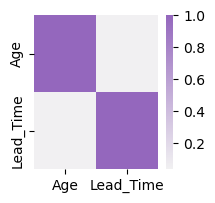

Age        Lead_Time    0.034901
Lead_Time  Age          0.034901
dtype: float64


In [15]:
# CORRELATION MATRIX

# Correlation is designed for continuous variables.
# Strictly speaking none of them are, but discrete variables with enough levels should still give meaningful results.

df_corr = df[['Age', 'Lead_Time']]
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize = (2,2))
sns.heatmap(corr_matrix, cmap = sns.light_palette('#9467bd', as_cmap=True))
plt.show()

c = corr_matrix.abs()
s = c.unstack()
so = s.sort_values(ascending = False)
so = so[so < 1]
print(so)

# No multicollinearity here to remove.

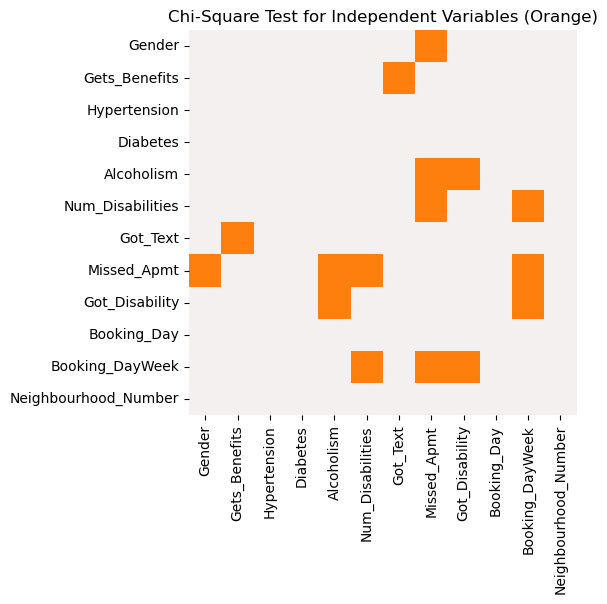

Alcoholism              0.96520
Gender                  0.18921
Num_Disabilities        0.10922
Booking_DayWeek         0.09951
Got_Disability          0.01280
Gets_Benefits           0.00000
Hypertension            0.00000
Diabetes                0.00000
Got_Text                0.00000
Missed_Apmt             0.00000
Booking_Day             0.00000
Neighbourhood_Number    0.00000
Name: Missed_Apmt, dtype: float64


In [16]:
# CHI SQUARED TEST

# Testing if categorical variables are independent.
# Matrix code adapted from: https://medium.com/analytics-vidhya/constructing-heat-map-for-chi-square-test-of-independence-6d78aa2b140f

#print(df.dtypes)

df_chi = df.drop(['Age', 'Lead_Time', 'Patient_ID', 'Apmt_ID'], axis = 'columns').astype('float') #need float to work.
# Num_Disabilities is not categorical, but since it's only got a few values it should work okay.
# Can't use Apmt_ID in the model because it's unique.
# If use Patient_ID the model won't generalise to new patients. We'd use it to calculate previous missed appointments if the
# data covered a longer period.

column_names = df_chi.columns
#print(column_names)

chisqmatrix=pd.DataFrame(df_chi, columns=column_names, index=column_names)
#print(df_chi.dtypes)

outercnt=0
innercnt=0

for icol in column_names: # Outer loop
    for jcol in column_names: # inner loop
     # Converting to cross tab as for CHi-square test we have to first convert variables into contigency table
        mycrosstab=pd.crosstab(df_chi[icol], df_chi[jcol])
         #Getting p-value and other useful information
        stat, p, dof, expected = chi2_contingency(mycrosstab)
        if icol==jcol:
            chisqmatrix.iloc[outercnt,innercnt]=0.00
        else:
            # Expected frequencies should be at least 5 for the majority (80%) of the cells, or the chi test doesn't work.
            # Here we are checking expected frequency of each group
            cntexpected=expected[expected<5].size
            #Getting percentage 
            perexpected=((expected.size-cntexpected)/expected.size)*100
            if perexpected<20:
                chisqmatrix.iloc[outercnt,innercnt] = 2 #Assigning 2
            else:
                chisqmatrix.iloc[outercnt, innercnt] = round(p,5)
        innercnt=innercnt+1
    outercnt=outercnt+1
    innercnt = 0
    
#print(chisqmatrix)

# Heatmap
# For this, I only care if p < 0.05 or not, but I still want to keep the original p values for later.
chisq_heat = chisqmatrix.mask(chisqmatrix >= 0.05, 1).mask(chisqmatrix < 0.05, 0)
#print(chisq_heat)
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(chisq_heat, cmap = sns.light_palette('#ff7f0e', as_cmap=True), cbar = False)
plt.title('Chi-Square Test for Independent Variables (Orange)')
plt.show()
# In the heatmap, variables with p >= 0.05 show as orange.

c = chisqmatrix.abs()
s = c.unstack()
so = s.sort_values(ascending = False)
so = so[so < 0.05]
#print(so)

chi_miss = chisqmatrix['Missed_Apmt'].sort_values(ascending = False)
print(chi_miss)

# Best features by Chi2 Score
# Unlike with the p-value, higher is better.

X = df.loc[:, ~ df.columns.isin(['Missed_Apmt', 'Patient_ID', 'Apmt_ID', 'Age', 'Lead_Time'])]
# Remove target, non-categorical variables and the IDs.
y = df['Missed_Apmt']

selector = SelectKBest(score_func=chi2, k = 'all')
kbest = selector.fit_transform(X,y)

feature_scores = selector.scores_
selected_features = X.columns[selector.get_support()]

scores = pd.Series(data = feature_scores, index = selected_features).sort_values(ascending = False)

#print(scores)

In [17]:
# MUTUAL INFORMATION

mi_score = mutual_info_classif(df.loc[:, ~ df.columns.isin(['Missed_Apmt', 'Patient_ID', 'Apmt_ID'])],df['Missed_Apmt'], random_state = 123)
# Mutual information will take any type of variable, as long as it's encoded to a number.
# bigger scores suggest more dependency.

mi = pd.Series(mi_score)
mi.index = df.loc[:, ~ df.columns.isin(['Missed_Apmt', 'Patient_ID', 'Apmt_ID'])].columns
mi = mi.sort_values(ascending=False)
#print(mi)

print('The MI Score for Gender and Missed_Apmt is ', mi['Gender'], 'which supports assumption of independence.')

The MI Score for Gender and Missed_Apmt is  0.0022664262301226312 which supports assumption of independence.


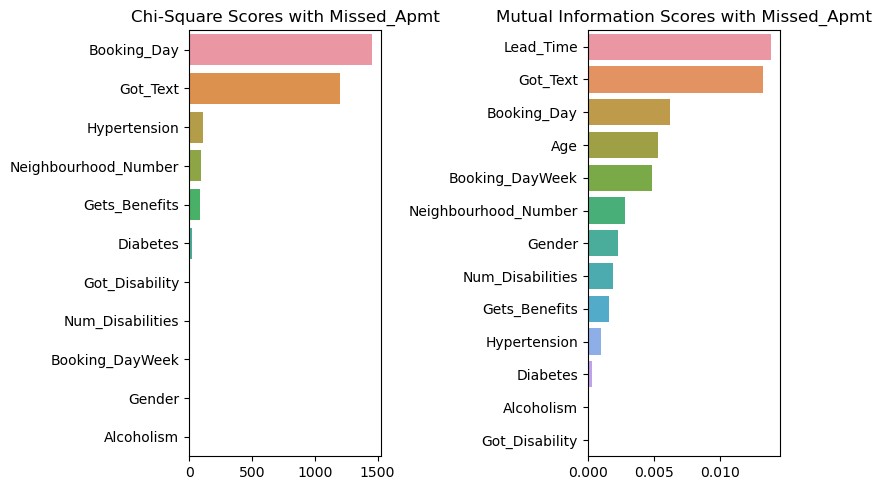

In [18]:
# CHI2 AND MI VISUALISATION

fig, ax = plt.subplots(1,2, figsize = (8,5))
sns.barplot(x = scores.values, y = scores.index, ax = ax[0])
ax[0].set_title('Chi-Square Scores with Missed_Apmt')

sns.barplot(x = mi.values, y = mi.index, ax = ax[1])
ax[1].set_title("Mutual Information Scores with Missed_Apmt")

plt.tight_layout()

In [19]:
# SPLITTING

# Chosen features
features = ['Gender', 'Lead_Time', 'Got_Text', 'Age', 'Neighbourhood_Number', 'Booking_Day']
# Need Gender to check bias.

x = df[features]
y = df['Missed_Apmt']

# Convert categorical variables so model knows non-ordinal.
x.loc[:, x.columns.isin(['Gender', 'Got_Text', 'Neighbourhood_Number'])] = x.loc[:, x.columns.isin(['Gender', 'Got_Text', 'Neighbourhood_Number'])].astype('category')
y = y.astype('category')
print(x.dtypes, 'Y dtype:', y.dtype)

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 123, stratify =  y)
# stratify keeps the proportion of missed appointments the same in both sets.

print(x.shape, x_train.shape, x_test.shape)

Gender                  category
Lead_Time                  int32
Got_Text                category
Age                        int64
Neighbourhood_Number    category
Booking_Day                int32
dtype: object Y dtype: category
(110300, 6) (82725, 6) (27575, 6)


In [20]:
# BALANCING

print(y_train.value_counts())

# Using oversampling to reduce data loss.

oversample = RandomOverSampler(sampling_strategy='minority', random_state = 123)
x_train, y_train = oversample.fit_resample(x_train, y_train)
print("Oversampled class distribution:", Counter(y_train))


Missed_Apmt
0    66015
1    16710
Name: count, dtype: int64
Oversampled class distribution: Counter({0: 66015, 1: 66015})


In [21]:
# SCALING

# If this model were going into production, would cross-validate and use a pipeline to scale within each fold to prevent data leakage.

scaler = RobustScaler()
# Robust scaler is most resistant to outliers, because it uses the median and IQR.Boxplot shows plenty of outliers in Lead_Time at least.
x_train_scaled = scaler.fit_transform(x_train)
X_train = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_test_scaled = scaler.transform(x_test) # Using same scaler on test set for consistency.
X_test = pd.DataFrame(x_test_scaled, columns = x_test.columns)

In [22]:
# LOGISTIC REGRESSION
# LR is a solid, fast classifier.

model_search = LogisticRegression(random_state = 123, n_jobs = -1) #n_jobs just speeds it up.

#param_grid = {'C': [0.01, 0.1,1.0,10,100,1000]} #0.01
param_grid = {'C': [0.01, 0.02, 0.03, 0.04, 0.05]} # Still 0.01, stick with that.

search = GridSearchCV(model_search, param_grid, scoring = 'precision', cv=5, n_jobs = -1)
# Because false positives are more of a problem than false negatives, I want to maximise precision rather than accuracy.
search.fit(X_train, y_train)

print(f"Best hyperparameters found: {search.best_params_}")

model = search.best_estimator_
model.fit(X_train, y_train)

Best hyperparameters found: {'C': 0.01}


LogisticRegression(C=0.01, n_jobs=-1, random_state=123)

In [23]:
# MODEL EVALUATION

# On training data
train_pred = model.predict(X_train)
print("Accuracy on training data: ", metrics.accuracy_score(y_train, train_pred))
print("Precision on training data: ", metrics.precision_score(y_train, train_pred))
print("Recall on training data: ", metrics.recall_score(y_train, train_pred))

print('')

# On testing data
test_pred = model.predict(X_test)
print("Accuracy on testing data: ", metrics.accuracy_score(y_test, test_pred))
print("Precision on testing data: ", metrics.precision_score(y_test, test_pred))
print("Recall on testing data: ", metrics.recall_score(y_test, test_pred))

Accuracy on training data:  0.6292887980004545
Precision on training data:  0.6469271819590291
Recall on training data:  0.569264561084602

Accuracy on testing data:  0.6637896645512239
Precision on testing data:  0.31441179420318927
Recall on testing data:  0.5628366247755835


TN=15169, FP=6836, FN=2435, TP=3135
Calculated accuracy =  0.6637896645512239
Calculated precision =  0.31441179420318927
Calculated recall =  0.5628366247755835


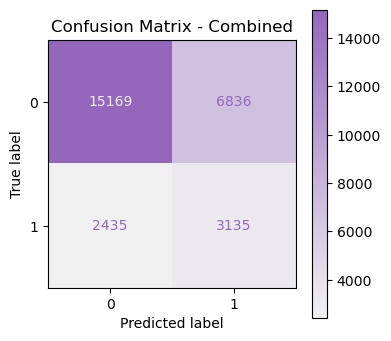

In [24]:
# CONFUSION MATRIX

cm = metrics.confusion_matrix(y_test, test_pred)
TN, FP, FN, TP = cm.ravel()
print("TN={0}, FP={1}, FN={2}, TP={3}".format(TN, FP, FN, TP))

disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap = sns.light_palette('#9467bd', as_cmap=True))
fig = disp.ax_.get_figure() 
fig.set_figwidth(4)
fig.set_figheight(4)  
plt.title('Confusion Matrix - Combined')

calculated_accuracy = (TP+TN)/(TP+TN+FP+FN)
calculated_precision = (TP)/(TP+FP)
calculated_recall = (TP)/(TP+FN)
print("Calculated accuracy = ", calculated_accuracy)
print("Calculated precision = ", calculated_precision)
print("Calculated recall = ", calculated_recall)
# Matches above, so should be correct.

In [25]:
# PROTECTED CLASS SPLIT

gender_dist = X_test['Gender'].value_counts()
print(gender_dist)

men_indices = np.where(X_test['Gender'] == 1)[0]
women_indices = np.where(X_test['Gender'] == 0)[0]
print(men_indices, "No of Men =", men_indices.size)
print(women_indices, "No of Women =", women_indices.size)

y_test_m = [y_test.values[i] for i in men_indices]
y_test_w = [y_test.values[i] for i in women_indices]
print(y_test_m, y_test_w)

y_pred_m = [test_pred[i] for i in men_indices]
y_pred_w = [test_pred[i] for i in women_indices]
print(y_pred_m, y_pred_w)

Gender
0.0    18003
1.0     9572
Name: count, dtype: int64
[    0     3     7 ... 27567 27570 27571] No of Men = 9572
[    1     2     4 ... 27572 27573 27574] No of Women = 18003
[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 

TN_m=5394, FP_m=2255, FN_m=872, TP_m=1051
Calculated accuracy (Men) =  0.673318010865023
Calculated precision (Men) =  0.3179068360556564
Calculated recall (Men) =  0.5465418616744669
TN_w=9775, FP_w=4581, FN_w=1563, TP_w=2084
Calculated accuracy (Women) =  0.6587235460756541
Calculated precision (Women) =  0.3126781695423856
Calculated recall (Women) =  0.5714285714285714


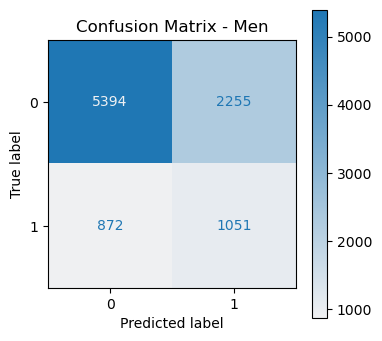

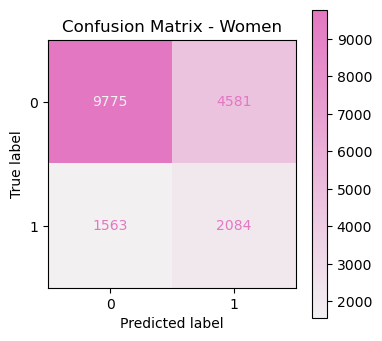

In [26]:
# PROTECTED CLASS CONFUSION MATRICES

# Men

cm_m = metrics.confusion_matrix(y_test_m, y_pred_m)
TN_m, FP_m, FN_m, TP_m = cm_m.ravel()
print("TN_m={0}, FP_m={1}, FN_m={2}, TP_m={3}".format(TN_m, FP_m, FN_m, TP_m))

disp_m = metrics.ConfusionMatrixDisplay(confusion_matrix = cm_m)
disp_m.plot(cmap = sns.light_palette('#1f77b4', as_cmap=True))
disp_m.ax_.set_title('Confusion Matrix - Men')
fig = disp_m.ax_.get_figure() 
fig.set_figwidth(4)
fig.set_figheight(4)

calculated_accuracy_m = (TP_m + TN_m)/(TP_m + TN_m + FP_m + FN_m)
calculated_precision_m = (TP_m)/(TP_m + FP_m)
calculated_recall_m = (TP_m)/(TP_m + FN_m)
print("Calculated accuracy (Men) = ", calculated_accuracy_m)
print("Calculated precision (Men) = ", calculated_precision_m)
print("Calculated recall (Men) = ", calculated_recall_m)

# Women

cm_w = metrics.confusion_matrix(y_test_w, y_pred_w)
TN_w, FP_w, FN_w, TP_w = cm_w.ravel()
print("TN_w={0}, FP_w={1}, FN_w={2}, TP_w={3}".format(TN_w, FP_w, FN_w, TP_w))

disp_w = metrics.ConfusionMatrixDisplay(confusion_matrix = cm_w)
disp_w.plot(cmap = sns.light_palette('#e377c2', as_cmap=True))
disp_w.ax_.set_title('Confusion Matrix - Women')
fig = disp_w.ax_.get_figure() 
fig.set_figwidth(4)
fig.set_figheight(4)

calculated_accuracy_w = (TP_w + TN_w)/(TP_w + TN_w + FP_w + FN_w)
calculated_precision_w = (TP_w)/(TP_w + FP_w)
calculated_recall_w = (TP_w)/(TP_w + FN_w)
print("Calculated accuracy (Women) = ", calculated_accuracy_w)
print("Calculated precision (Women) = ", calculated_precision_w)
print("Calculated recall (Women) = ", calculated_recall_w)



In [27]:
# FAIRNESS METRICS

# Equal Accuracy
ac_comp = round(calculated_accuracy_w / calculated_accuracy_m, 2)
ac_dif = round(calculated_accuracy_m - calculated_accuracy_w, 2)
pre_comp = round(calculated_precision_w / calculated_precision_m, 2)
pre_dif = round(calculated_precision_m - calculated_precision_w, 2)

# Demographic Parity (equal positive rate)

pr_m = (TP_m + FP_m) / (𝑇𝑃_m + 𝑇𝑁_m + 𝐹𝑃_m + 𝐹𝑁_m)
pr_w = (TP_w + FP_w) / (𝑇𝑃_w + 𝑇𝑁_w + 𝐹𝑃_w + 𝐹𝑁_w)
pr_comp = round(pr_w / pr_m,2)
pr_dif = round(pr_m - pr_w,2)

# Equal Opportunity (equal true positive rate)

tpr_m = 𝑇𝑃_m / (𝑇𝑃_m + 𝐹𝑁_m)
tpr_w = 𝑇𝑃_w / (𝑇𝑃_w + 𝐹𝑁_w)
tpr_comp = round(tpr_w / tpr_m, 2)
tpr_dif = round(tpr_m - tpr_w, 2)

# Equalised Odds (equal TPR and equal FPR)

fpr_m = FP_m / (TN_m + FP_m)
fpr_w = FP_w / (TN_w + FP_w)
fpr_comp = round(fpr_w / fpr_m, 2)
fpr_dif = round(fpr_m - fpr_w, 2)

# Negative Rates

nr_m = (TN_m + FN_m) / (𝑇𝑃_m + 𝑇𝑁_m + 𝐹𝑃_m + 𝐹𝑁_m)
nr_w = (TN_w + FN_w) / (𝑇𝑃_w + 𝑇𝑁_w + 𝐹𝑃_w + 𝐹𝑁_w)
nr_comp = round(nr_w / nr_m,2)
nr_dif = round(nr_m - nr_w,2)

tnr_m = TN_m / (TN_m + FP_m)
tnr_w = TN_w / (TN_w + FP_w)
tnr_comp = round(tnr_w / tnr_m, 2)
tnr_dif = round(tnr_m - tnr_w, 2)

fnr_m = FN_m / (𝑇𝑃_m + 𝐹𝑁_m)
fnr_w = FN_w / (𝑇𝑃_w + 𝐹𝑁_w)
fnr_comp = round(fnr_w / fnr_m, 2)
fnr_dif = round(fnr_m - fnr_w, 2)

# Results Table

df_comp = pd.DataFrame(
    {
     'Metric': ['Accuracy', 'Precision', 'Positive Rate', 'True Positive Rate (Recall)', 'False Positive Rate', 'Negative Rate', 'True Negative Rate', 'False Negative Rate'],
     'Men': [calculated_accuracy_m, calculated_precision_m, pr_m, tpr_m, fpr_m, nr_m, tnr_m, fnr_m],
     'Women': [calculated_accuracy_w, calculated_precision_w, pr_w, tpr_w, fpr_w, nr_w, tnr_w, fnr_w],
     'Comparison W/M': [ac_comp, pre_comp, pr_comp, tpr_comp, fpr_comp, nr_comp, tnr_comp, fnr_comp],
     'Difference M-W': [ac_dif, pre_dif, pr_dif, tpr_dif, fpr_dif, nr_dif, tnr_dif, fnr_dif]
    }
)

df_comp



,Metric,Men,Women,Comparison W/M,Difference M-W
0,Accuracy,0.673318,0.658724,0.98,0.01
1,Precision,0.317907,0.312678,0.98,0.01
2,Positive Rate,0.345382,0.370216,1.07,-0.02
3,True Positive Rate (Recall),0.546542,0.571429,1.05,-0.02
4,False Positive Rate,0.294810,0.319100,1.08,-0.02
5,Negative Rate,0.654618,0.629784,0.96,0.02
6,True Negative Rate,0.705190,0.680900,0.97,0.02
7,False Negative Rate,0.453458,0.428571,0.95,0.02


In [28]:
# FAIRNESS TESTS

ea_pass = "Yes" if ac_comp >= 0.8 else "No"
dp_pass = "Yes" if pr_comp >= 0.8 else "No"
eops_pass = "Yes" if tpr_dif < 0.05 else "No"
eodd_pass = "Yes" if (eops_pass == "Yes" and fpr_dif < 0.05) else "No"

df_fair = pd.DataFrame(
    {
      'Test': ['Equal Accuracy', 'Demographic Parity', 'Equal Opportunity', 'Equalised Odds'],
      'Threshold': ['>= 0.80', '>= 0.80', '< 0.05', '< 0.05'],
      'Actual Value(s)': [ac_comp, pr_comp, tpr_dif, (tpr_dif, fpr_dif)],
      'Passed?': [ea_pass, dp_pass, eops_pass, eodd_pass]
    }
)

df_fair

,Test,Threshold,Actual Value(s),Passed?
0,Equal Accuracy,>= 0.80,0.98,Yes
1,Demographic Parity,>= 0.80,1.07,Yes
2,Equal Opportunity,< 0.05,-0.02,Yes
3,Equalised Odds,< 0.05,"(-0.02, -0.02)",Yes
